In [2]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
from datasets import load_dataset

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

In [5]:
df.job_posted_date = pd.to_datetime(df.job_posted_date)
df['job_skills'] = df['job_skills'].apply(lambda skill: ast.literal_eval(skill) if pd.notna(skill) else skill)

## 🟩 Job Postings Trend for Cloud Engineers (2.16.1) - Problem

Create a line plot showing the trend of job postings over the months for Cloud Engineer job postings:

  * Create a new DataFrame called df_ce that filters only job postings that are 'Cloud Engineer'
  * Customize the plot by setting the line style to dotted, the line color to purple, and the marker style to 'o'.
  * Add a title 'Job Postings Trend for Cloud Engineers' and label the y-axis as 'Count of Job Postings'.

In [68]:
df_CE = df[df['job_title_short'] == 'Cloud Engineer'].copy()

df_CE['job_posted_month'] = df['job_posted_date'].dt.month_name()


df_CE_counts = df_CE.job_posted_month.value_counts().reset_index(name='job_counts')

df_CE_counts['job_posted_month_no'] = pd.to_datetime(df_CE_counts['job_posted_month']).dt.month



C:\Users\hieno\AppData\Local\Temp\ipykernel_5072\447395382.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_CE_counts['job_posted_month_no'] = pd.to_datetime(df_CE_counts['job_posted_month']).dt.month


In [69]:
df_CE_counts = df_CE_counts.sort_values(by='job_posted_month_no')
df_CE_counts = df_CE_counts.set_index('job_posted_month')
df_CE_counts = df_CE_counts.drop(columns=['job_posted_month_no'])

Text(0, 0.5, 'Count of Job Postings')

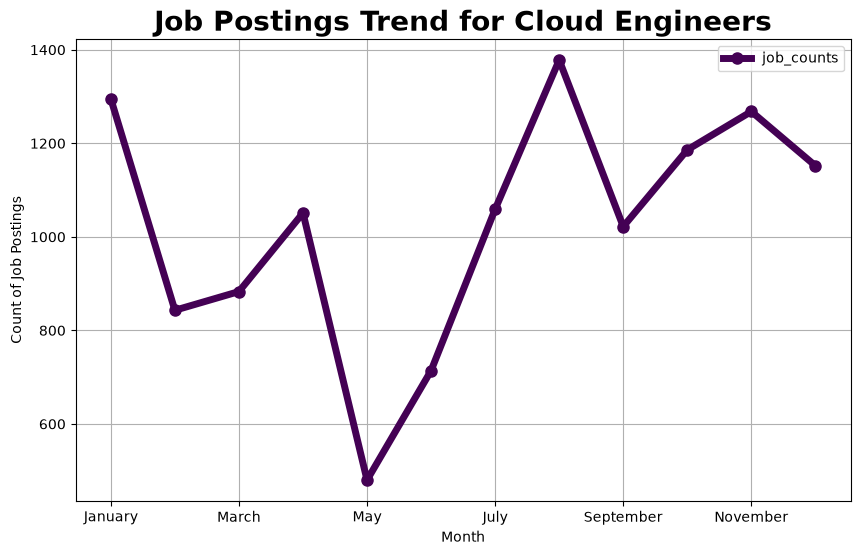

In [70]:
df_CE_counts.plot(
                    kind = 'line'
                    , linewidth = 5
                    , linestyle = '-'
                    , colormap = 'viridis'
                    , markersize = 8
                    , marker = 'o'
                    , figsize = (10, 6) )

plt.grid(True)
plt.title(
        'Job Postings Trend for Cloud Engineers'
        , fontdict={'fontsize': 20, 'fontweight': 'bold'})

plt.xlabel(
            'Month'
            , fontdict={'fontsize': 10}
            )

plt.ylabel(
            'Count of Job Postings'
            , fontdict={'fontsize': 10}
            )

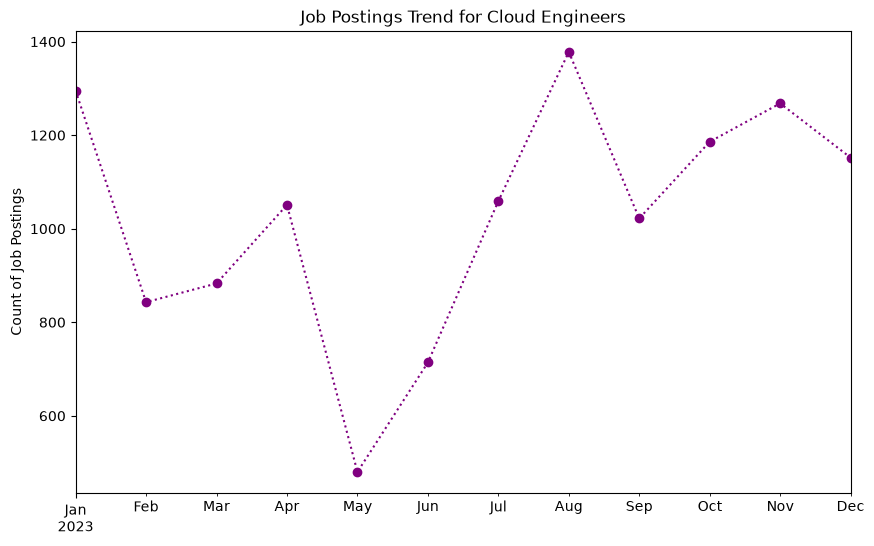

In [65]:
df_ce = df[df['job_title_short'] == 'Cloud Engineer'].copy()
df_ce['job_posted_month'] = df_ce['job_posted_date'].dt.to_period('M')
monthly_job_postings = df_ce.groupby('job_posted_month').size()
monthly_job_postings.plot( kind='line',  linestyle=':',  color='purple',  marker='o', figsize=(10, 6) )
plt.title('Job Postings Trend for Cloud Engineers')
plt.ylabel('Count of Job Postings')
plt.xlabel('')
plt.show()

## 🟨 Customize Bar Chart (2.16.2) - Problem

Create a bar chart showing the top 5 job companies hiring for Senior Data Analyst roles:

  * Create a DataFrame called SDA_df. 
  * Customize the plot by setting the bar colors to 5 different colors with the variable colors.
  * Add a grid to the y-axis only and making it dashes.
  * Rotate the x-axis labels by 45 degrees.
  * Label the y-axis as 'Number of Job Postings' and set the title to 'Top 5 Companies hiring Senior Data Analysts by Number of Postings'; Make the font size 14.

In [80]:
colors = ['blue', 'orange', 'green', 'red', 'purple']

In [81]:
df_SDA = df.copy()[df['job_title_short'] == 'Senior Data Analyst']

df_SDA_counts = df_SDA.groupby('company_name').size().sort_values(ascending=False).head()

df_SDA_counts = df_SDA_counts.reset_index(name='job_counts')

<Figure size 1000x600 with 0 Axes>

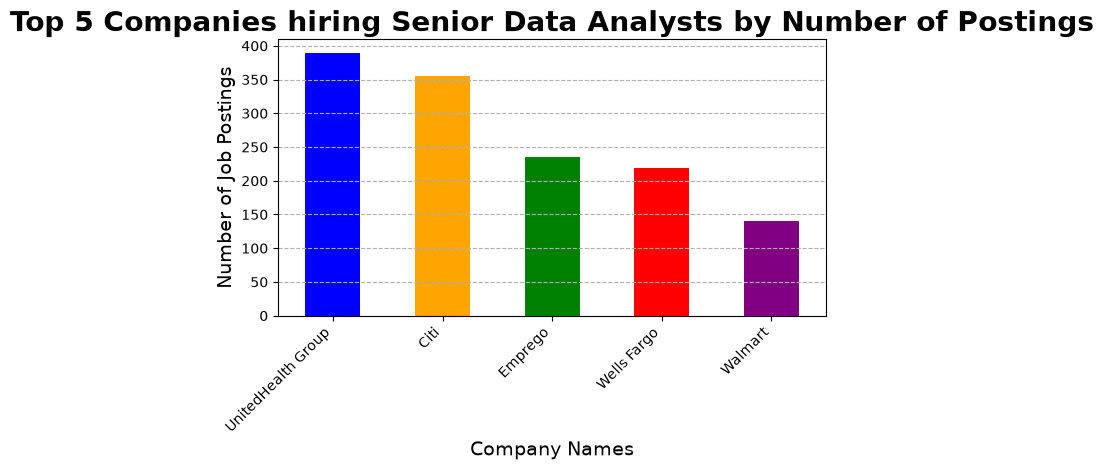

In [113]:
plt.figure(figsize=(10,6))
df_SDA_counts.plot(
                    kind='bar'
                    , x = 'company_name'
                    , y = 'job_counts'
                    , color=colors
                    )

plt.title(
            'Top 5 Companies hiring Senior Data Analysts by Number of Postings'
            , fontdict={'fontsize': 20, 'fontweight': 'bold'})

plt.xlabel(
            'Company Names'
            , fontdict={'fontsize': 14}
            )

plt.ylabel(
            'Number of Job Postings'
            , fontdict={'fontsize': 14}
            )

plt.xticks(
            rotation = 45
            , ha = 'right')

plt.grid(
        linestyle = '--'
        , axis = 'y')

plt.legend().set_visible(False)
plt.tight_layout()
plt.show()
